In [2]:
import sys
sys.path.insert(0, "..")

import json
from pathlib import Path

%load_ext autoreload
%autoreload 2

ROOT = Path().cwd().parent
ROOT

PosixPath('/Users/I550854/Documents/Master Thesis/gdpa-benchmark')

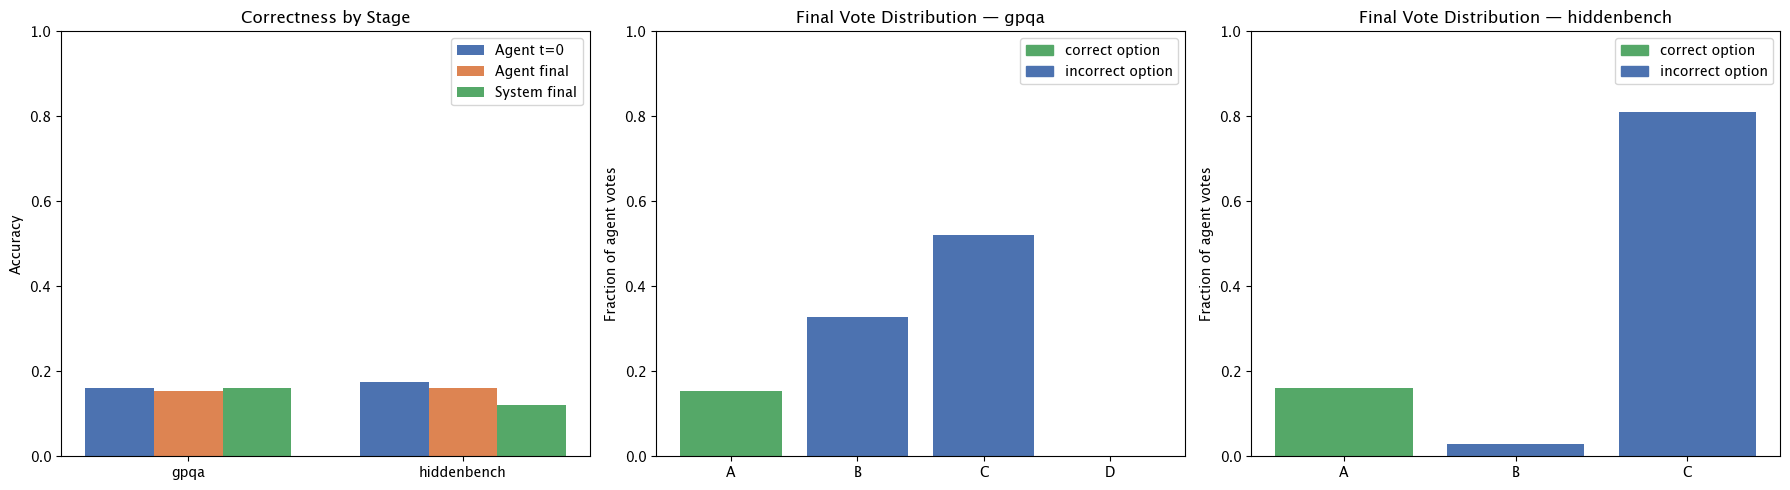

In [7]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

FILES = {
    'gpqa': 'results/mas/20260506_171459_gpqa_gpt-4o_N3_T3_W1_temp1.0_q56_R50.json',
    'hiddenbench': 'results/mas/20260507_100659_hiddenbench_gpt-4o_N4_T3_W1_temp1.0_q0_R50.json',
}

data = {}
for name, path in FILES.items():
    with open(ROOT / path) as f:
        data[name] = json.load(f)

def agent_votes_at_round(rep, round_idx):
    return [agent['vote'] for agent in rep['trajectory'][round_idx]['phase_b']]

def is_agent_correct_at_round(rep, round_idx):
    gt = rep['ground_truth']
    return [v == gt for v in agent_votes_at_round(rep, round_idx)]

records = []
vote_dist_records = []

for name, d in data.items():
    for rep in d['repetitions']:
        gt = rep['ground_truth']
        records.append({
            'dataset': name,
            'agent_correct_t0': np.mean(is_agent_correct_at_round(rep, 0)),
            'agent_correct_final': np.mean(is_agent_correct_at_round(rep, -1)),
            'system_correct': float(rep['correct']),
        })
        for vote in agent_votes_at_round(rep, -1):
            vote_dist_records.append({'dataset': name, 'vote': vote, 'ground_truth': gt})

df = pd.DataFrame(records)
vote_df = pd.DataFrame(vote_dist_records)
datasets = list(data.keys())

summary = df.groupby('dataset')[['agent_correct_t0', 'agent_correct_final', 'system_correct']].mean()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Correctness bars
x = np.arange(len(summary))
width = 0.25
for i, (col, label, color) in enumerate(zip(
    ['agent_correct_t0', 'agent_correct_final', 'system_correct'],
    ['Agent t=0', 'Agent final', 'System final'],
    ['#4C72B0', '#DD8452', '#55A868']
)):
    axes[0].bar(x + i * width, summary[col], width, label=label, color=color)

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(summary.index)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Correctness by Stage')
axes[0].legend()
axes[0].set_ylim(0, 1)

# Vote distributions
for ax, ds in zip(axes[1:], datasets):
    sub = vote_df[vote_df['dataset'] == ds]
    option_order_ds = sorted(data[ds]['repetitions'][0]['options'].keys())
    counts = sub['vote'].value_counts(normalize=True).reindex(option_order_ds, fill_value=0)
    gt_vals = set(sub['ground_truth'].unique())
    bar_colors = ['#55A868' if opt in gt_vals else '#4C72B0' for opt in option_order_ds]

    ax.bar(option_order_ds, counts.values, color=bar_colors)
    ax.set_ylabel('Fraction of agent votes')
    ax.set_title(f'Final Vote Distribution — {ds}')
    ax.set_ylim(0, 1)
    ax.legend(handles=[
        Patch(color='#55A868', label='correct option'),
        Patch(color='#4C72B0', label='incorrect option'),
    ])

plt.tight_layout()
plt.show()


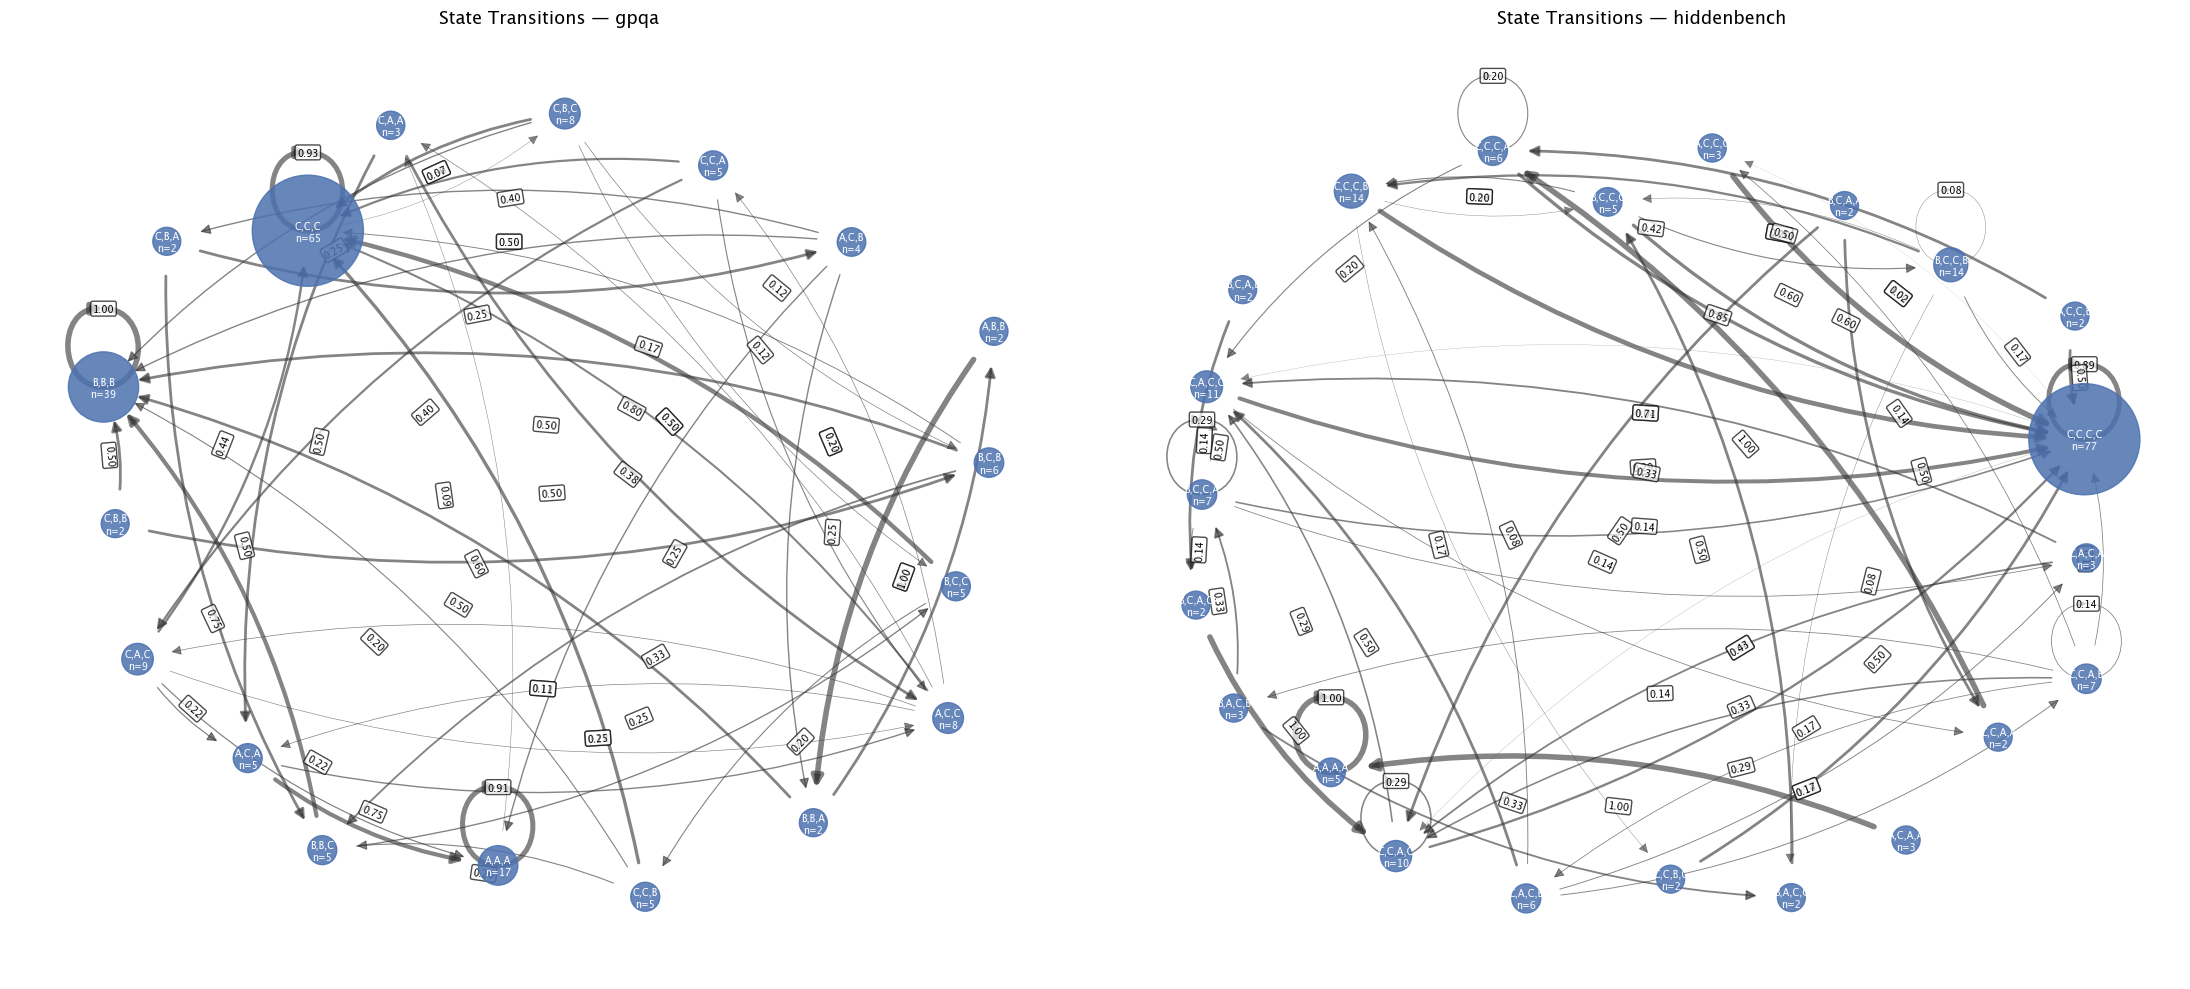

In [14]:
import json
import matplotlib.pyplot as plt
import networkx as nx
from collections import defaultdict

FILES = {
    'gpqa': 'results/mas/20260506_171459_gpqa_gpt-4o_N3_T3_W1_temp1.0_q56_R50.json',
    'hiddenbench': 'results/mas/20260507_100659_hiddenbench_gpt-4o_N4_T3_W1_temp1.0_q0_R50.json',
}

MIN_VISITS = 2

data = {}
for name, path in FILES.items():
    with open(ROOT / path) as f:
        data[name] = json.load(f)

def build_transition_graph(d):
    transition_counts = defaultdict(lambda: defaultdict(int))
    visit_counts = defaultdict(int)

    for rep in d['repetitions']:
        states = [
            tuple(agent['vote'] for agent in step['phase_b'])
            for step in rep['trajectory']
        ]
        for s in states:
            visit_counts[s] += 1
        for s1, s2 in zip(states, states[1:]):
            transition_counts[s1][s2] += 1

    G = nx.DiGraph()
    for state, count in visit_counts.items():
        G.add_node(state, visits=count)
    for from_s, to_dict in transition_counts.items():
        total = sum(to_dict.values())
        for to_s, count in to_dict.items():
            G.add_edge(from_s, to_s, weight=count / total)

    return G

def plot_transition_graph(G, title, ax, min_visits=1):
    visible = {n for n, d in G.nodes(data=True) if d['visits'] >= min_visits}
    G = G.subgraph(visible).copy()

    pos = nx.spring_layout(G, seed=42, k=2.5)

    max_visits = max(d['visits'] for _, d in G.nodes(data=True))
    node_sizes = [400 + (G.nodes[n]['visits'] / max_visits) ** 2 * 6000 for n in G.nodes()]
    node_labels = {n: f"{','.join(n)}\nn={G.nodes[n]['visits']}" for n in G.nodes()}
    edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
    edge_widths = [d['weight'] * 4 for _, _, d in G.edges(data=True)]

    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='#4C72B0', alpha=0.85, ax=ax)
    nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=7, font_color='white', ax=ax)
    nx.draw_networkx_edges(
        G, pos, width=edge_widths, alpha=0.6, edge_color='#333333',
        arrows=True, arrowsize=15, ax=ax,
        connectionstyle='arc3,rad=0.15',
        min_source_margin=25, min_target_margin=25,
    )
    nx.draw_networkx_edge_labels(
        G, pos, edge_labels=edge_labels, font_size=7, ax=ax,
        bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7),
    )
    ax.set_title(title, fontsize=13)
    ax.axis('off')

fig, axes = plt.subplots(1, 2, figsize=(22, 10))

for ax, (name, d) in zip(axes, data.items()):
    G = build_transition_graph(d)
    plot_transition_graph(G, f'State Transitions — {name}', ax, min_visits=MIN_VISITS)

plt.tight_layout()
plt.show()


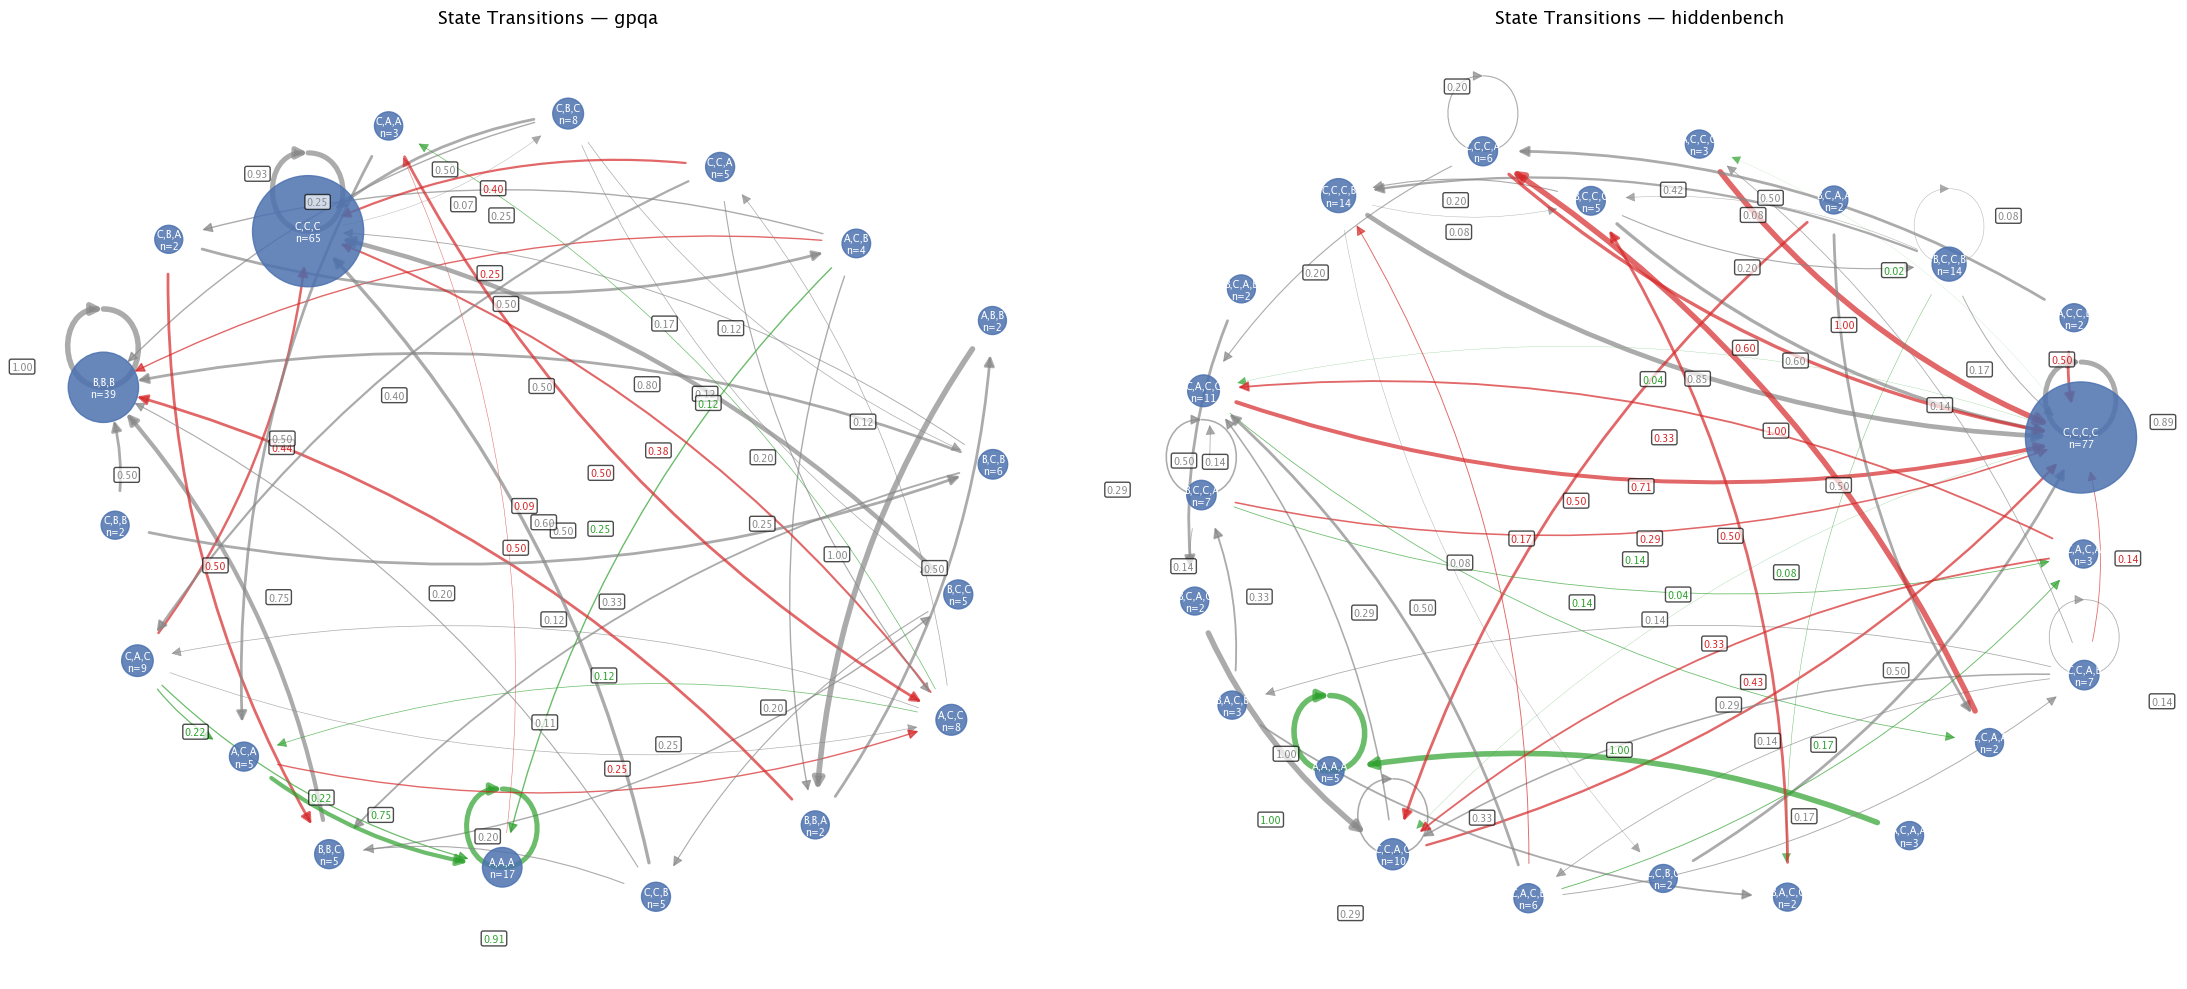

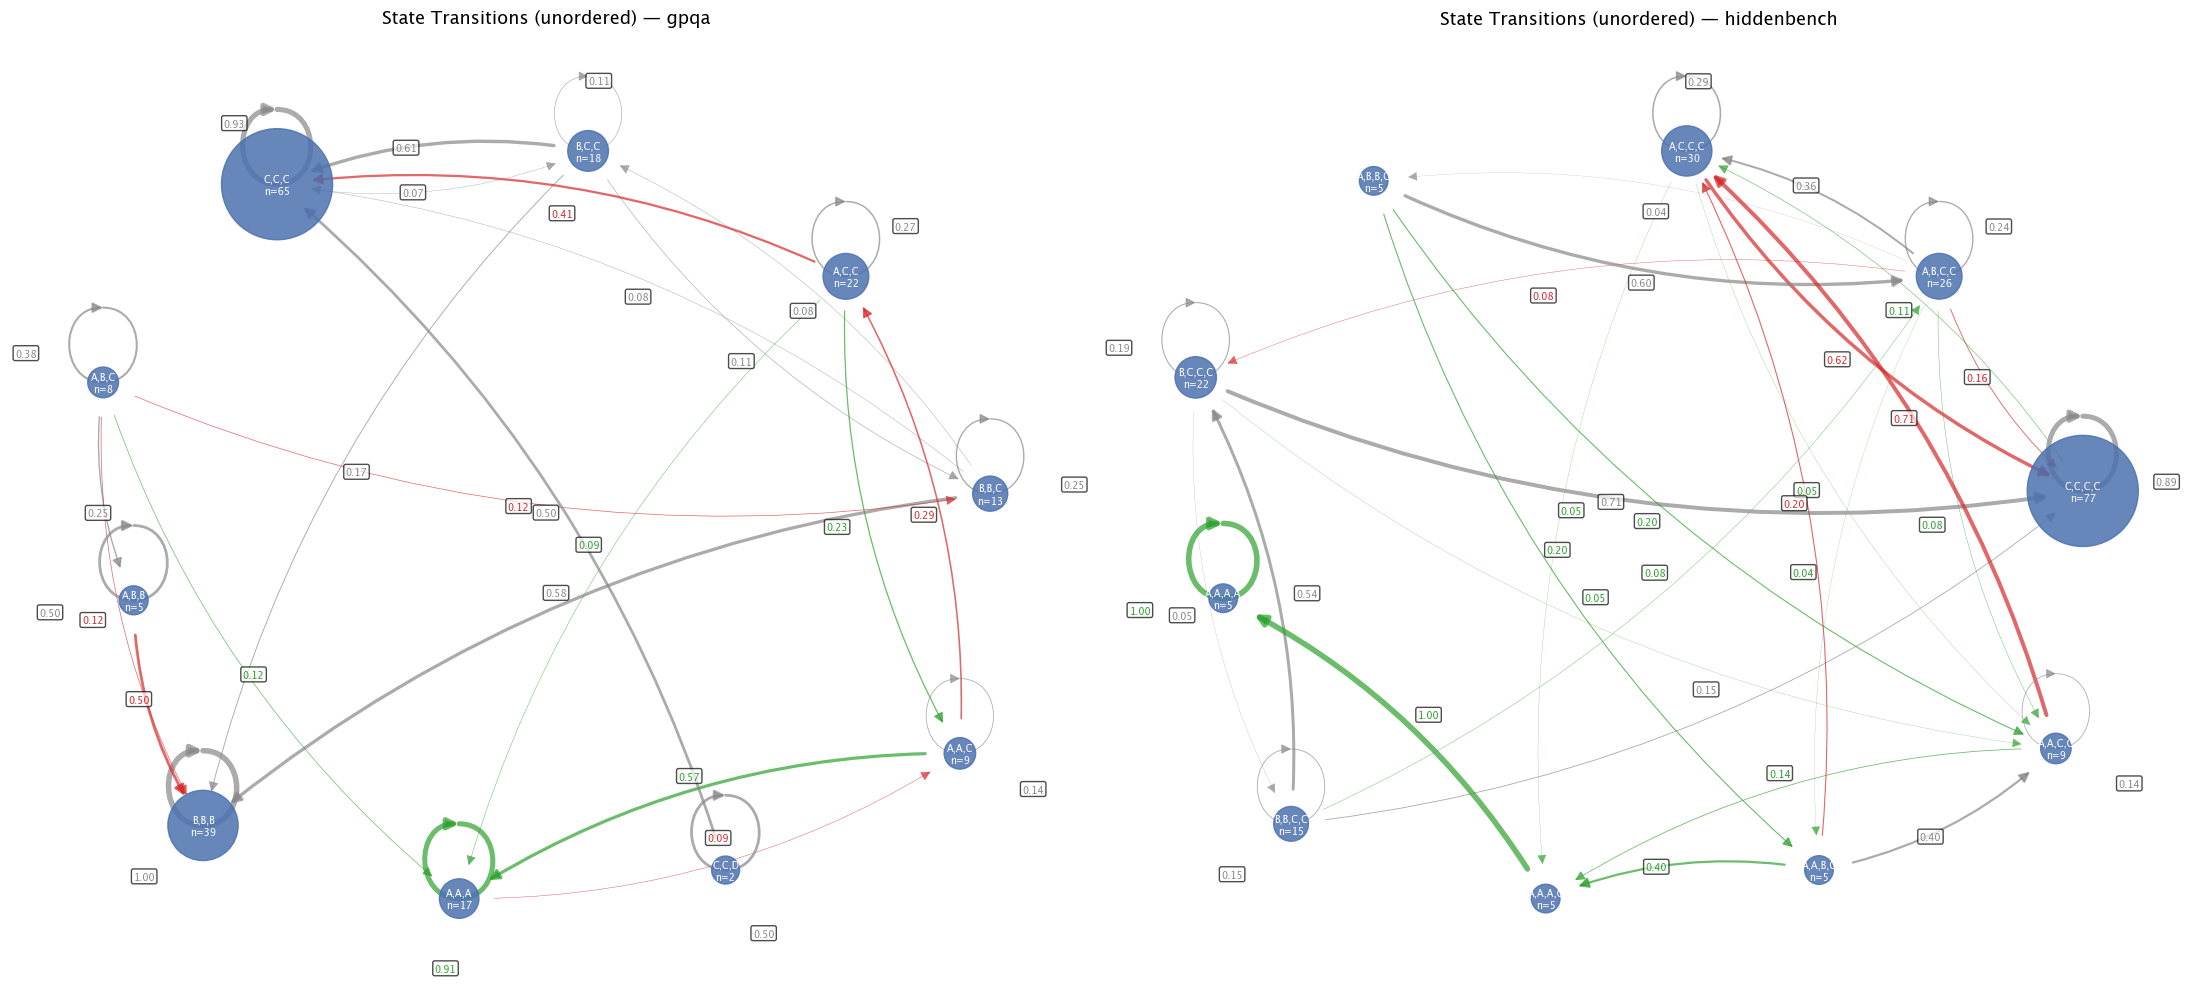

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from collections import defaultdict

FILES = {
    'gpqa': 'results/mas/20260506_171459_gpqa_gpt-4o_N3_T3_W1_temp1.0_q56_R50.json',
    'hiddenbench': 'results/mas/20260507_100659_hiddenbench_gpt-4o_N4_T3_W1_temp1.0_q0_R50.json',
}

MIN_VISITS = 2
ARC_RAD = 0.15

data = {}
for name, path in FILES.items():
    with open(ROOT / path) as f:
        data[name] = json.load(f)

def build_transition_graph(d, unordered=False):
    transition_counts = defaultdict(lambda: defaultdict(int))
    visit_counts = defaultdict(int)

    for rep in d['repetitions']:
        states = [
            tuple(sorted(agent['vote'] for agent in step['phase_b']) if unordered
                  else [agent['vote'] for agent in step['phase_b']])
            for step in rep['trajectory']
        ]
        for s in states:
            visit_counts[s] += 1
        for s1, s2 in zip(states, states[1:]):
            transition_counts[s1][s2] += 1

    G = nx.DiGraph()
    for state, count in visit_counts.items():
        G.add_node(state, visits=count)
    for from_s, to_dict in transition_counts.items():
        total = sum(to_dict.values())
        for to_s, count in to_dict.items():
            G.add_edge(from_s, to_s, weight=count / total)

    return G

def draw_arc_edge_labels(pos, edge_labels, edge_colors, ax, rad=ARC_RAD, font_size=7):
    all_positions = np.array(list(pos.values()))
    centroid = all_positions.mean(axis=0)

    for (u, v), label in edge_labels.items():
        p1 = np.array(pos[u])
        p2 = np.array(pos[v])
        color = edge_colors.get((u, v), '#888888')

        if u == v:
            away = p1 - centroid
            away_norm = np.linalg.norm(away)
            direction = away / away_norm if away_norm > 0 else np.array([0.0, 1.0])
            label_pos = p1 + direction * 0.18
        else:
            dx, dy = p2 - p1
            label_pos = (p1 + p2) / 2 + 0.5 * rad * np.array([dy, -dx])
            dists = np.linalg.norm(all_positions - label_pos, axis=1)
            nearest = all_positions[np.argmin(dists)]
            away = label_pos - nearest
            away_norm = np.linalg.norm(away)
            if away_norm > 0:
                label_pos += 0.05 * away / away_norm

        ax.text(
            label_pos[0], label_pos[1], label,
            fontsize=font_size, ha='center', va='center', zorder=5,
            color=color, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7),
        )

def plot_transition_graph(G, title, ax, gt, min_visits=1):
    visible = {n for n, d in G.nodes(data=True) if d['visits'] >= min_visits}
    G = G.subgraph(visible).copy()

    pos = nx.spring_layout(G, seed=42, k=4.0)

    def correct_count(state):
        return sum(1 for v in state if v == gt)

    max_visits = max(d['visits'] for _, d in G.nodes(data=True))
    node_sizes = [400 + (G.nodes[n]['visits'] / max_visits) ** 2 * 6000 for n in G.nodes()]
    node_labels = {n: f"{','.join(n)}\nn={G.nodes[n]['visits']}" for n in G.nodes()}
    edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
    edge_widths = [d['weight'] * 4 for _, _, d in G.edges(data=True)]

    edge_color_map = {}
    for u, v in G.edges():
        if u == v:
            edge_color_map[(u, v)] = '#2ca02c' if correct_count(u) == len(u) else '#888888'
        else:
            delta = correct_count(v) - correct_count(u)
            if delta > 0:
                edge_color_map[(u, v)] = '#2ca02c'
            elif delta < 0:
                edge_color_map[(u, v)] = '#d62728'
            else:
                edge_color_map[(u, v)] = '#888888'

    edge_colors = [edge_color_map[(u, v)] for u, v in G.edges()]

    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='#4C72B0', alpha=0.85, ax=ax)
    nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=7, font_color='white', ax=ax)
    nx.draw_networkx_edges(
        G, pos, width=edge_widths, alpha=0.7, edge_color=edge_colors,
        arrows=True, arrowsize=15, ax=ax,
        connectionstyle=f'arc3,rad={ARC_RAD}',
        min_source_margin=25, min_target_margin=25,
    )
    draw_arc_edge_labels(pos, edge_labels, edge_color_map, ax)
    ax.set_title(title, fontsize=13)
    ax.axis('off')

fig, axes = plt.subplots(1, 2, figsize=(22, 10))
for ax, (name, d) in zip(axes, data.items()):
    gt = d['repetitions'][0]['ground_truth']
    G = build_transition_graph(d)
    plot_transition_graph(G, f'State Transitions — {name}', ax, gt=gt, min_visits=MIN_VISITS)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(22, 10))
for ax, (name, d) in zip(axes, data.items()):
    gt = d['repetitions'][0]['ground_truth']
    G = build_transition_graph(d, unordered=True)
    plot_transition_graph(G, f'State Transitions (unordered) — {name}', ax, gt=gt, min_visits=MIN_VISITS)
plt.tight_layout()
plt.show()

# flips not oversable right now
# number of history, use what the others are already using --> easier to defend it
# variables to change: t,
# swapping view points, risk factors / loss, extra rounds in history might help for example as an recommendation
# what are features / reasons why agents escape a situation, how to break the loop 
# everything based on prev literature to defend, even if not peer reviewed. But rounds of history and stuff like this should be from literature

# TODO: find very common ground of knobs / things to change and stick to it. At leaset some grounding. Should max switch 2-3 knobs --> Ali likes the number of rounds, memory, agentsq

"""
Things we can change / modify:

- Agent definition:
--> system prompt (output format, cooperativeness, thinking, should they see votes, confidence scores, agentic devil)
--> access to tools (calculator, websearch, ...)
--> information asymmetry
--> number of agents

- Communication definition:
--> topology
--> asymmetry / symmetry (turn based communication?) (could name it scratchpad with an intermediate step to stick with symmetry)
--> number of rounds
--> size of context window / round memory

- LLMs:
--> diverse or the same models
--> choice of model strength
--> randomness parameters like temperatur

- Initialization:
--> start with wrong / correct answers (maybe makes more sense for the perturbation later)


"""

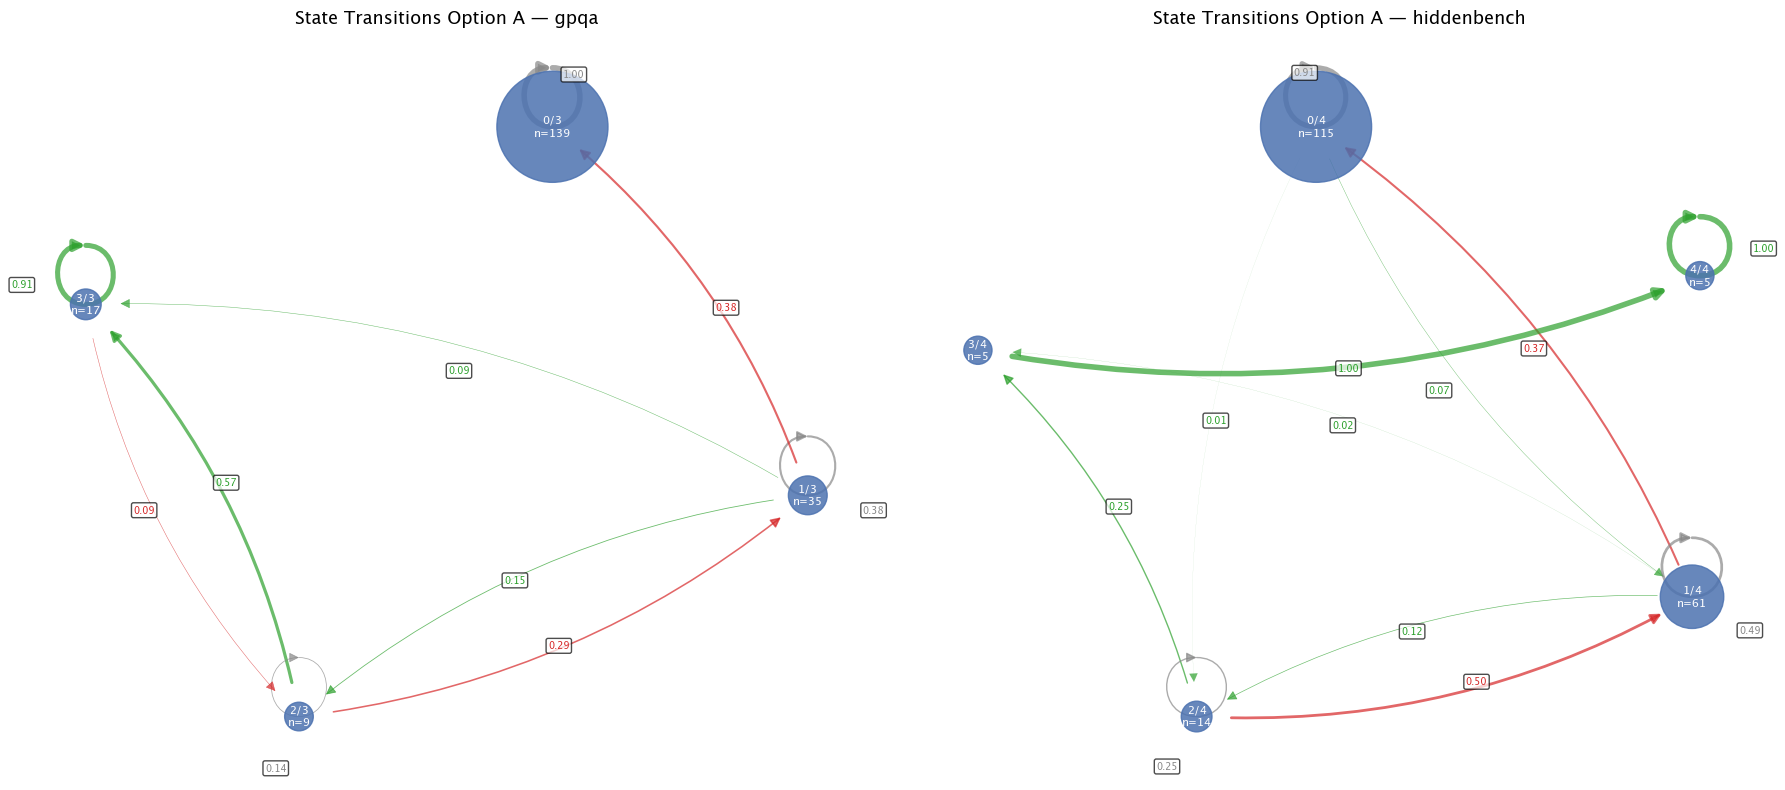

In [28]:
def build_transition_graph_option_a(d):
    transition_counts = defaultdict(lambda: defaultdict(int))
    visit_counts = defaultdict(int)
    gt = d['repetitions'][0]['ground_truth']

    for rep in d['repetitions']:
        states = [
            sum(1 for agent in step['phase_b'] if agent['vote'] == gt)
            for step in rep['trajectory']
        ]
        for s in states:
            visit_counts[s] += 1
        for s1, s2 in zip(states, states[1:]):
            transition_counts[s1][s2] += 1

    N = d['repetitions'][0]['N']
    G = nx.DiGraph()
    for k in range(N + 1):
        G.add_node(k, visits=visit_counts.get(k, 0))
    for from_s, to_dict in transition_counts.items():
        total = sum(to_dict.values())
        for to_s, count in to_dict.items():
            G.add_edge(from_s, to_s, weight=count / total)

    return G, N

def plot_transition_graph_option_a(G, N, title, ax):
    pos = nx.spring_layout(G, seed=42, k=4.0)

    max_visits = max(d['visits'] for _, d in G.nodes(data=True)) or 1
    node_sizes = [400 + (G.nodes[n]['visits'] / max_visits) ** 2 * 6000 for n in G.nodes()]
    node_labels = {n: f"{n}/{N}\nn={G.nodes[n]['visits']}" for n in G.nodes()}
    edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
    edge_widths = [d['weight'] * 4 for _, _, d in G.edges(data=True)]

    edge_color_map = {}
    for u, v in G.edges():
        if u == v:
            edge_color_map[(u, v)] = '#2ca02c' if u == N else '#888888'
        elif v > u:
            edge_color_map[(u, v)] = '#2ca02c'
        else:
            edge_color_map[(u, v)] = '#d62728'
    edge_colors = [edge_color_map[(u, v)] for u, v in G.edges()]

    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='#4C72B0', alpha=0.85, ax=ax)
    nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=8, font_color='white', ax=ax)
    nx.draw_networkx_edges(
        G, pos, width=edge_widths, alpha=0.7, edge_color=edge_colors,
        arrows=True, arrowsize=15, ax=ax,
        connectionstyle=f'arc3,rad={ARC_RAD}',
        min_source_margin=25, min_target_margin=25,
    )
    draw_arc_edge_labels(pos, edge_labels, edge_color_map, ax)
    ax.set_title(title, fontsize=13)
    ax.axis('off')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
for ax, (name, d) in zip(axes, data.items()):
    G, N = build_transition_graph_option_a(d)
    plot_transition_graph_option_a(G, N, f'State Transitions Option A — {name}', ax)
plt.tight_layout()
plt.show()
